#### ロジスティック回帰による予測

ファーストリテイリング株が指数のリターンを超えるかどうか予測

In [1]:
# データの読み込み

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data_07/stock_price_9983.csv", index_col='Date')
df.head(20)

# "^N225"が日経平均株価
# "9983.T"がファストリ(Tは東京証券取引所の意味)

,^N225,9983.T
Date,,
2016-03-30,16878.960938,34949.539062
2016-03-31,16758.669922,34489.929688
2016-04-01,16164.160156,32622.761719
2016-04-04,16123.269531,31990.794922
2016-04-05,15732.820312,30659.839844
2016-04-06,15715.360352,30295.984375
2016-04-07,15749.839844,29194.832031
2016-04-08,15821.519531,25479.648438
2016-04-11,15751.129883,25675.941406


In [2]:
# 欠損値の除去

df = df.dropna()
df.head(10)

,^N225,9983.T
Date,,
2016-03-30,16878.960938,34949.539062
2016-03-31,16758.669922,34489.929688
2016-04-01,16164.160156,32622.761719
2016-04-04,16123.269531,31990.794922
2016-04-05,15732.820312,30659.839844
2016-04-06,15715.360352,30295.984375
2016-04-07,15749.839844,29194.832031
2016-04-08,15821.519531,25479.648438
2016-04-11,15751.129883,25675.941406


In [3]:
# リターンの計算

df_rate = pd.DataFrame()
df_rate['^N225 1 day return'] = df['^N225'].pct_change()
df_rate['9983 1 day return'] = df['9983.T'].pct_change()
df_rate = df_rate.dropna()
df_rate.head(10)

,^N225 1 day return,9983 1 day return
Date,,
2016-03-31,-0.007127,-0.013151
2016-04-01,-0.035475,-0.054137
2016-04-04,-0.002530,-0.019372
2016-04-05,-0.024217,-0.041604
2016-04-06,-0.001110,-0.011867
2016-04-07,0.002194,-0.036346
2016-04-08,0.004551,-0.127255
2016-04-11,-0.004449,0.007704
2016-04-12,0.011279,0.003729


In [4]:
# リターンの差を計算

df_rate['diff'] =  df_rate['9983 1 day return'].shift(-1) - df_rate['^N225 1 day return'].shift(-1)
df_rate['target'] = (df_rate['diff'] > 0).astype(int) # ファストリのリターンが上回れば1/そうでなければ0
df_rate = df_rate.dropna()
df_rate.head()

,^N225 1 day return,9983 1 day return,diff,target
Date,,,,
2016-03-31,-0.007127,-0.013151,-0.018662,0
2016-04-01,-0.035475,-0.054137,-0.016842,0
2016-04-04,-0.002530,-0.019372,-0.017388,0
2016-04-05,-0.024217,-0.041604,-0.010758,0
2016-04-06,-0.001110,-0.011867,-0.038540,0


In [5]:
# ロジスティック回帰のためのセッティング
# 説明変数: 9983 1 day return
# 目的変数: target

from sklearn.model_selection import train_test_split

X = df_rate['9983 1 day return']
y = df_rate['target']

# 検証データセットのサイズは20%
# データのシャッフルはしないでおく

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

# ファストリのリターンが日経225を上回った日の割合

print(np.sum(y_train[y_train > 0]) / len(y_train))

0.4948770491803279


In [6]:
# ロジスティック回帰の実行

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(penalty=None)
log_reg.fit(X_train.values.reshape(-1, 1), y_train.values)

# 回帰係数と切片

print(log_reg.coef_)
print(log_reg.intercept_)

[[-4.21772516]]
[-0.01866656]


In [7]:
# 日時リターン0.3を予測モデルに入力したときの確率と予測ラベル

print(log_reg.predict_proba([[0.3]]))
print(log_reg.predict([[0.3]]))

[[0.7831272 0.2168728]]
[0]


In [8]:
# 日時リターンを-0.5としてみる

print(log_reg.predict([[-0.5]]))

[1]


In [9]:
# 予測モデルの精度を正答率で評価

from sklearn.metrics import accuracy_score

y_train_pred = log_reg.predict(X_train.values.reshape(-1, 1))
print('accuracy score for train data: {0:.4f}'.format(accuracy_score(y_train, y_train_pred)))

accuracy score for train data: 0.5266


In [10]:
# 日経平均のリターンも説明変数に追加

X = df_rate[df_rate.columns[(df_rate.columns != 'diff') & (df_rate.columns != 'target')]]
y = df_rate['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

log_reg = LogisticRegression(penalty=None)
log_reg.fit(X_train, y_train)
y_train_pred = log_reg.predict(X_train)

print('accuracy score for train data: {0:.4f}'.format(accuracy_score(y_train,y_train_pred)))

accuracy score for train data: 0.5205


In [11]:
# 今までは前日と今日とのリターンのみを説明変数としていた
# このインターバルをいろいろと変えてみる

diffs = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240]

for diff in diffs:
    df_rate['^N225 {0:d} days return'.format(diff)] = df['^N225'].pct_change(diff)
    df_rate['9983 {0:d} days return'.format(diff)] = df['9983.T'].pct_change(diff)

df_rate = df_rate.dropna(how='any')

X = df_rate[df_rate.columns[(df_rate.columns != 'diff') & (df_rate.columns != 'target')]]
y = df_rate['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

log_reg = LogisticRegression(penalty=None, max_iter=2000)
log_reg.fit(X_train, y_train)
y_train_pred = log_reg.predict(X_train)

print('accuracy score for train data: {0:.4f}'.format(accuracy_score(y_train,y_train_pred)))

accuracy score for train data: 0.5987


In [12]:
# 偏回帰係数と切片

print(log_reg.coef_)
print(log_reg.intercept_)

[[-1.30802086e+01 -1.27904644e+00  1.22395087e+01 -7.66073602e+00
  -7.31306958e+00 -1.98848883e+00 -1.05800163e+01  1.48479586e+01
   1.65606975e+01 -7.92646795e+00  4.50605139e+00 -7.95061208e+00
  -3.74273300e+00  3.71507022e+00 -2.63629505e+01  1.46621505e+01
   3.53696222e+01 -1.58769900e+01 -1.18425447e+01  6.51087310e+00
  -2.35087507e+00 -6.59279785e+00  1.20718216e-01  7.46686325e-01
  -1.39631163e+01  7.29663418e+00  2.29087177e-02  1.23750214e+00
   3.44724132e+01 -1.45617394e+01 -2.36094095e+01  2.38638138e+00
   4.02849504e+00  7.17374822e+00  4.01075216e+00 -4.61148123e+00
  -5.03319339e+00 -4.65639358e-01  1.26259209e+00  1.82035017e+00
   2.57626982e+00  1.48907543e-03 -3.22521937e+00  2.70558196e+00
   1.85234805e+00 -1.14846682e-01 -6.20229473e-02 -3.94193332e+00
   2.33403780e+00  3.23157196e+00 -5.34215903e+00 -1.10185852e-01
   1.57695840e+00  6.29772786e-01 -1.80978770e-01 -2.97914864e-01
   4.91881351e-01 -9.75799315e-01 -7.33469827e+00 -4.30372271e-02
   6.41863

In [13]:
# データの標準化と最小最大スケーリングを試してみる

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_ss = StandardScaler()
scaler_mm = MinMaxScaler(feature_range=(-1, 1)) # 区間を[-1, 1]に決め打ち
X_train_scaled_ss = scaler_ss.fit_transform(X_train)
X_train_scaled_mm = scaler_mm.fit_transform(X_train)

# 標準化データでロジスティック回帰

log_reg_ss = LogisticRegression(penalty=None, max_iter=2000)
log_reg_ss.fit(X_train_scaled_ss, y_train)
y_train_pred_ss = log_reg_ss.predict(X_train_scaled_ss)
print('Accuracy score: {0:.4f}'.format(accuracy_score(y_train, y_train_pred_ss)))

# 最小最大スケーリングでロジスティック回帰

log_reg_mm = LogisticRegression(penalty=None, max_iter=2000)
log_reg_mm.fit(X_train_scaled_mm, y_train)
y_train_pred_mm = log_reg_ss.predict(X_train_scaled_mm)
print('Accuracy score: {0:.4f}'.format(accuracy_score(y_train,y_train_pred_mm)))

Accuracy score: 0.6038
Accuracy score: 0.6115


In [14]:
# 検証データで性能を評価

y_val_pred = log_reg.predict(X_val)
print('Accuracy score for validation data: {0:.4f}'.format(accuracy_score(y_val, y_val_pred)))

Accuracy score for validation data: 0.4619


In [15]:
# 標準化と最小最大スケーリング後のデータもチェック

X_val_scaled_ss = scaler_ss.fit_transform(X_val)
y_val_pred_ss = log_reg_ss.predict(X_val_scaled_ss)

X_val_scaled_mm = scaler_mm.fit_transform(X_val)
y_val_pred_mm = log_reg_mm.predict(X_val_scaled_ss)

print('Accuracy score for validation data, standard scaler: {0:.4f}'.format(accuracy_score(y_val, y_val_pred_ss)))
print('Accuracy score for validation data, min-max scaler: {0:.4f}'.format(accuracy_score(y_val, y_val_pred_mm)))

Accuracy score for validation data, standard scaler: 0.4569
Accuracy score for validation data, min-max scaler: 0.4721


In [16]:
# 過学習をしている雰囲気があるのでLasso正則化を試みる

log_reg_l1 = LogisticRegression(penalty='l1', solver='saga', C=1)
log_reg_l1.fit(X_train,y_train)

y_train_pred_l1 = log_reg_l1.predict(X_train)
y_val_pred_l1 = log_reg_l1.predict(X_val)

# 偏回帰係数と切片

print('coef',log_reg_l1.coef_) 
print('intercept',log_reg_l1.intercept_) 

coef [[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.43538152
   0.          0.21359941  0.          0.          0.         -0.39367618
   0.          0.48927588  0.          0.          0.          0.
   0.          0.          0.         -0.13480817 -0.3700291  -0.98213281
   0.          0.46776074]]
intercept [0.13993095]


In [17]:
# 正答率

print('Accuracy score: {0:.4f}'.format(accuracy_score(y_train,y_train_pred_l1)))
print('Accuracy score: {0:.4f}'.format(accuracy_score(y_val,y_val_pred_l1)))

# 過学習はマシになったか
# 精度50%以上の予測器があれば統計的裁定が可能 [Easley et al., 2021]

Accuracy score: 0.5732
Accuracy score: 0.5178


#### 多クラス分類

リターンの差が大幅+/大幅-/それ以外という形の問題を設定

In [18]:
# データの整理

df_rate = pd.DataFrame()
df_rate['^N225 1 day return'] = df['^N225'].pct_change()
df_rate['9983 1 day return'] = df['9983.T'].pct_change()
df_rate = df_rate.dropna()

# "大幅"=日経225の標準偏差より変動が大きい

df_vol = df_rate['^N225 1 day return'].std()
df_rate.loc[df_rate['9983 1 day return'].shift(-1) > df_rate['^N225 1 day return'].shift(-1) + df_vol, 'target'] = 0 # 大幅+
df_rate.loc[(df_rate['9983 1 day return'].shift(-1) < df_rate['^N225 1 day return'].shift(-1) + df_vol) 
            & (df_rate['9983 1 day return'].shift(-1) > df_rate['^N225 1 day return'].shift(-1) - df_vol),'target'] = 1 # それ以外
df_rate.loc[df_rate['9983 1 day return'].shift(-1) < df_rate['^N225 1 day return'].shift(-1) - df_vol, 'target'] = 2 # 大幅-

df_rate = df_rate.dropna()
df_rate['target'] = df_rate['target'].astype(int)
df_rate.head(10)

,^N225 1 day return,9983 1 day return,target
Date,,,
2016-03-31,-0.007127,-0.013151,2
2016-04-01,-0.035475,-0.054137,2
2016-04-04,-0.002530,-0.019372,2
2016-04-05,-0.024217,-0.041604,1
2016-04-06,-0.001110,-0.011867,2
2016-04-07,0.002194,-0.036346,2
2016-04-08,0.004551,-0.127255,1
2016-04-11,-0.004449,0.007704,1
2016-04-12,0.011279,0.003729,0


In [19]:
# 様々なインターバルを用意

diffs = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240]
    
for diff in diffs:
    df_rate['^N225 {0:d} days return'.format(diff)] = df['^N225'].pct_change(diff)
    df_rate['9983 {0:d} days return'.format(diff)] = df['9983.T'].pct_change(diff)

df_rate = df_rate.dropna(how='any')

X = df_rate[df_rate.columns[(df_rate.columns!='target')]]
y = df_rate['target']


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

# softmax回帰で予測

log_reg_trino = LogisticRegression(multi_class='multinomial', penalty=None, max_iter=2000)
log_reg_trino.fit(X_train, y_train)
y_train_pred = log_reg_trino.predict(X_train)
y_val_pred = log_reg_trino.predict(X_val)

print('Accuracy score: {0:.4f}'.format(accuracy_score(y_train,y_train_pred)))
print('Accuracy score: {0:.4f}'.format(accuracy_score(y_val,y_val_pred)))

Accuracy score: 0.7121
Accuracy score: 0.6294


/Users/shimizutoorushin/Desktop/大学講義/M1_Class_program/M1_Class/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [20]:
# Lasso正則化

log_reg_trino =  LogisticRegression(multi_class='multinomial', penalty='l1', C=0.01, solver='saga')
log_reg_trino.fit(X_train, y_train)

y_train_pred_multi = log_reg_trino.predict(X_train)
y_val_pred_multi = log_reg_trino.predict(X_val)

print('Accuracy score: {0:.4f}'.format(accuracy_score(y_train,y_train_pred_multi)))
print('Accuracy score: {0:.4f}'.format(accuracy_score(y_val,y_val_pred_multi)))

# 正則化の影響が強く出た

Accuracy score: 0.6841
Accuracy score: 0.6701


/Users/shimizutoorushin/Desktop/大学講義/M1_Class_program/M1_Class/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### ニューラルネットワークで予測

日経平均とドル円レートからトヨタの上昇/下降を予測

In [21]:
# データの読み込み

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data_07/stock_price_7203.csv", index_col='Date')
df.head(20)

# "1306.T"がTOPIXのETF
# "7203.T"がトヨタ

,1306.T,7203.T
Date,,
2016-03-30,1407.0,953.277405
2016-03-31,1397.0,945.651184
2016-04-01,1346.0,916.893982
2016-04-04,1350.0,893.697632
2016-04-05,1314.0,864.146057
2016-04-06,1314.0,867.005859
2016-04-07,1319.0,861.762939
2016-04-08,1333.0,868.594666
2016-04-11,1329.0,838.566406


In [22]:
# データの整理

df_rate = pd.DataFrame()
df_rate['TOPIX 1 day return'] = df['1306.T'].pct_change()
df_rate['7203 1 day return'] = df['7203.T'].pct_change()
df_rate = df_rate.dropna()
df_rate['diff'] =  df_rate['7203 1 day return'].shift(-1) - df_rate['TOPIX 1 day return'].shift(-1)
df_rate['target'] = (df_rate['diff'] > 0).astype(int)
df_rate = df_rate.dropna()
df_rate.head(10)

,TOPIX 1 day return,7203 1 day return,diff,target
Date,,,,
2016-03-31,-0.007107,-0.008000,0.006097,1
2016-04-01,-0.036507,-0.030410,-0.028271,0
2016-04-04,0.002972,-0.025299,-0.006400,0
2016-04-05,-0.026667,-0.033067,0.003309,1
2016-04-06,0.000000,0.003309,-0.009852,0
2016-04-07,0.003805,-0.006047,-0.002686,0
2016-04-08,0.010614,0.007928,-0.031570,0
2016-04-11,-0.003001,-0.034571,0.024923,1
2016-04-12,0.014296,0.039219,0.001420,1


In [23]:
# 説明変数と目的変数の構築

from sklearn.model_selection import train_test_split

diffs = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240]
    
for diff in diffs:
    df_rate['TOPIX {0:d} days return'.format(diff)] = df['1306.T'].pct_change(diff)
    df_rate['7203 {0:d} days return'.format(diff)] = df['7203.T'].pct_change(diff)

df_rate = df_rate.dropna(how='any')

X = df_rate[df_rate.columns[(df_rate.columns != 'diff') & (df_rate.columns != 'target')]]
y = df_rate['target']

# 訓練/テストデータセットの作成

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

df_rate.head(10)

,TOPIX 1 day return,7203 1 day return,diff,target,TOPIX 2 days return,7203 2 days return,TOPIX 3 days return,7203 3 days return,TOPIX 4 days return,7203 4 days return,...,TOPIX 160 days return,7203 160 days return,TOPIX 180 days return,7203 180 days return,TOPIX 200 days return,7203 200 days return,TOPIX 220 days return,7203 220 days return,TOPIX 240 days return,7203 240 days return
Date,,,,,,,,,,,,,,,,,,,,,
2017-03-23,0.001275,-0.000162,0.003563,1,-0.019351,-0.033422,-0.021793,-0.034028,-0.026038,-0.045405,...,0.167162,0.067876,0.235063,0.259128,0.099370,0.083202,0.094011,0.071713,0.116560,0.044027
2017-03-24,0.007638,0.011201,0.000604,1,0.008923,0.011037,-0.011860,-0.022595,-0.014321,-0.023208,...,0.191121,0.081127,0.220509,0.237415,0.120311,0.100665,0.139669,0.120326,0.133142,0.064235
2017-03-27,-0.012003,-0.011398,-0.003684,0,-0.004456,-0.000325,-0.003187,-0.000487,-0.023720,-0.033736,...,0.165425,0.062458,0.207722,0.239534,0.132513,0.104626,0.161099,0.150703,0.161961,0.085102
2017-03-28,0.013427,0.009743,-0.004951,0,0.001263,-0.001766,0.008912,0.009415,0.010198,0.009252,...,0.181073,0.090761,0.217358,0.238132,0.142754,0.114210,0.178439,0.154279,0.174074,0.124114
2017-03-29,0.007571,0.002620,0.009148,1,0.021100,0.012389,0.008844,0.000849,0.016550,0.012060,...,0.211684,0.113010,0.219084,0.236533,0.154736,0.118706,0.179468,0.141467,0.215373,0.165601
2017-03-30,-0.011271,-0.002123,-0.002425,0,-0.003785,0.000491,0.009591,0.010239,-0.002527,-0.001275,...,0.224031,0.131910,0.211819,0.227682,0.135155,0.118897,0.141721,0.114364,0.201674,0.159290
2017-03-31,-0.008866,-0.011291,-0.001894,0,-0.020038,-0.013390,-0.012618,-0.010806,0.000639,-0.001167,...,0.200153,0.099071,0.250000,0.235153,0.117059,0.101006,0.133237,0.110191,0.186505,0.153174
2017-04-03,0.002556,0.000662,-0.003881,0,-0.006333,-0.010637,-0.017533,-0.012737,-0.010095,-0.010151,...,0.206923,0.068081,0.259230,0.233778,0.132852,0.117072,0.132035,0.127131,0.177044,0.144861
2017-04-04,-0.006373,-0.010255,-0.011251,0,-0.003834,-0.009599,-0.012666,-0.020782,-0.023795,-0.022861,...,0.176604,0.023084,0.270579,0.225474,0.130529,0.100901,0.140454,0.135822,0.173062,0.173697


In [24]:
# ロジスティック回帰

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(random_state=0)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_train)
print('accuracy score for train data: {0:.4f}'.format(accuracy_score(y_train, y_pred)))

y_val_pred = log_reg.predict(X_val)
print('accuracy score for valid data: {0:.4f}'.format(accuracy_score(y_val,y_val_pred)))

# これが比較対象

accuracy score for train data: 0.5750
accuracy score for valid data: 0.4975


In [25]:
# Kerasを用いてニューラルネットワークを構成

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

model = Sequential()
model.add(Dense(units=62, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
optimizer = optimizers.SGD(learning_rate=0.05)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# 学習開始

tf.random.set_seed(0)
model.fit(X_train.values, y_train.values, epochs=30, batch_size=1, verbose=2, validation_data=(X_val.values, y_val.values))

# 参考図書だとエポック数100だった

Epoch 1/30
800/800 - 1s - 627us/step - accuracy: 0.5100 - loss: 0.7502 - val_accuracy: 0.5622 - val_loss: 0.6844
Epoch 2/30
800/800 - 0s - 301us/step - accuracy: 0.5138 - loss: 0.7461 - val_accuracy: 0.5721 - val_loss: 0.6843
Epoch 3/30
800/800 - 0s - 315us/step - accuracy: 0.5138 - loss: 0.7429 - val_accuracy: 0.5821 - val_loss: 0.6847
Epoch 4/30
800/800 - 0s - 322us/step - accuracy: 0.5175 - loss: 0.7402 - val_accuracy: 0.5672 - val_loss: 0.6854
Epoch 5/30
800/800 - 0s - 315us/step - accuracy: 0.5238 - loss: 0.7377 - val_accuracy: 0.5423 - val_loss: 0.6862
Epoch 6/30
800/800 - 0s - 314us/step - accuracy: 0.5238 - loss: 0.7356 - val_accuracy: 0.5323 - val_loss: 0.6873
Epoch 7/30
800/800 - 0s - 442us/step - accuracy: 0.5250 - loss: 0.7335 - val_accuracy: 0.5224 - val_loss: 0.6884
Epoch 8/30
800/800 - 0s - 326us/step - accuracy: 0.5225 - loss: 0.7316 - val_accuracy: 0.5224 - val_loss: 0.6896
Epoch 9/30
800/800 - 0s - 316us/step - accuracy: 0.5213 - loss: 0.7298 - val_accuracy: 0.5274 - 

In [26]:
# 正答率

score_train = model.evaluate(X_train.values, y_train.values, verbose=0)
score_val = model.evaluate(X_val.values, y_val.values, verbose=0)
print('accuracy for train data: {0:.4f}'.format(score_train[1]))
print('accuracy for validation data: {0:.4f}'.format(score_val[1]))

accuracy for train data: 0.5612
accuracy for validation data: 0.4627


In [27]:
# 正則化で過学習の抑制

from tensorflow.keras.regularizers import l2

tf.random.set_seed(0)
model = Sequential()
for _ in range(10):
    model.add(Dense(62, activation='selu', kernel_initializer='lecun_normal', kernel_regularizer=l2(0.005))) # 活性化関数はSELU
model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.005)))
optimizer = optimizers.RMSprop(learning_rate=0.001, rho=0.99)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train.values, y_train.values, epochs=100, batch_size=10, verbose=2, validation_data=(X_val.values, y_val.values))

Epoch 1/100
80/80 - 1s - 10ms/step - accuracy: 0.5013 - loss: 3.5733 - val_accuracy: 0.4478 - val_loss: 3.0897
Epoch 2/100
80/80 - 0s - 914us/step - accuracy: 0.5050 - loss: 2.7789 - val_accuracy: 0.5075 - val_loss: 2.4641
Epoch 3/100
80/80 - 0s - 909us/step - accuracy: 0.5063 - loss: 2.2080 - val_accuracy: 0.5572 - val_loss: 1.9434
Epoch 4/100
80/80 - 0s - 954us/step - accuracy: 0.5275 - loss: 1.7302 - val_accuracy: 0.5622 - val_loss: 1.5135
Epoch 5/100
80/80 - 0s - 939us/step - accuracy: 0.5238 - loss: 1.3511 - val_accuracy: 0.5622 - val_loss: 1.1869
Epoch 6/100
80/80 - 0s - 951us/step - accuracy: 0.5275 - loss: 1.0757 - val_accuracy: 0.5622 - val_loss: 0.9641
Epoch 7/100
80/80 - 0s - 903us/step - accuracy: 0.5312 - loss: 0.8985 - val_accuracy: 0.5622 - val_loss: 0.8304
Epoch 8/100
80/80 - 0s - 874us/step - accuracy: 0.5312 - loss: 0.7972 - val_accuracy: 0.5622 - val_loss: 0.7583
Epoch 9/100
80/80 - 0s - 923us/step - accuracy: 0.5312 - loss: 0.7441 - val_accuracy: 0.5622 - val_loss: 

In [28]:
# 正答率

score_train = model.evaluate(X_train.values, y_train.values, verbose=0)
score_val = model.evaluate(X_val.values, y_val.values, verbose=0)
print('accuracy for train data: {0:.4f}'.format(score_train[1]))
print('accuracy for validation data: {0:.4f}'.format(score_val[1]))

accuracy for train data: 0.5312
accuracy for validation data: 0.5622


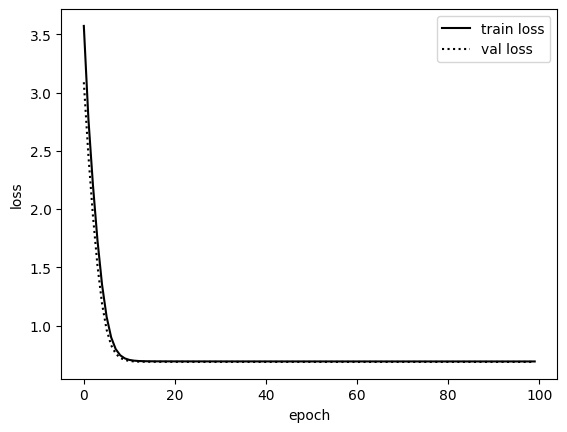

In [29]:
# 学習曲線

plt.plot(history.history['loss'], label='train loss', linestyle='solid', color='black')
plt.plot(history.history['val_loss'], label='val loss', linestyle='dotted', color='black')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc='best')

# 学習曲線は落ち着いている

In [30]:
# dropoutを導入して過学習を抑制

from tensorflow.keras.layers import Dropout

model = Sequential()
for _ in range(10):
    model.add(Dense(62, activation='selu', kernel_initializer='lecun_normal'))
    model.add(Dropout(0.5)) # dropout rate = 0.5
model.add(Dense(1,activation='sigmoid'))
optimizer = optimizers.RMSprop(learning_rate=0.001, rho=0.99)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
history_drop2 = model.fit(X_train.values, y_train.values, epochs=100, batch_size=10, verbose=2, validation_data=(X_val.values, y_val.values))

Epoch 1/100
80/80 - 1s - 10ms/step - accuracy: 0.5000 - loss: 1.6144 - val_accuracy: 0.4378 - val_loss: 0.7534
Epoch 2/100
80/80 - 0s - 973us/step - accuracy: 0.4875 - loss: 1.3060 - val_accuracy: 0.5871 - val_loss: 0.6863
Epoch 3/100
80/80 - 0s - 961us/step - accuracy: 0.5013 - loss: 1.0589 - val_accuracy: 0.4279 - val_loss: 0.7353
Epoch 4/100
80/80 - 0s - 1ms/step - accuracy: 0.4950 - loss: 1.0113 - val_accuracy: 0.5771 - val_loss: 0.6809
Epoch 5/100
80/80 - 0s - 1ms/step - accuracy: 0.5300 - loss: 0.8803 - val_accuracy: 0.6020 - val_loss: 0.6786
Epoch 6/100
80/80 - 0s - 1ms/step - accuracy: 0.4975 - loss: 0.9125 - val_accuracy: 0.5522 - val_loss: 0.6882
Epoch 7/100
80/80 - 0s - 1ms/step - accuracy: 0.5100 - loss: 0.8446 - val_accuracy: 0.4726 - val_loss: 0.6996
Epoch 8/100
80/80 - 0s - 988us/step - accuracy: 0.4863 - loss: 0.8373 - val_accuracy: 0.6020 - val_loss: 0.6833
Epoch 9/100
80/80 - 0s - 958us/step - accuracy: 0.5188 - loss: 0.7705 - val_accuracy: 0.5672 - val_loss: 0.6811
E

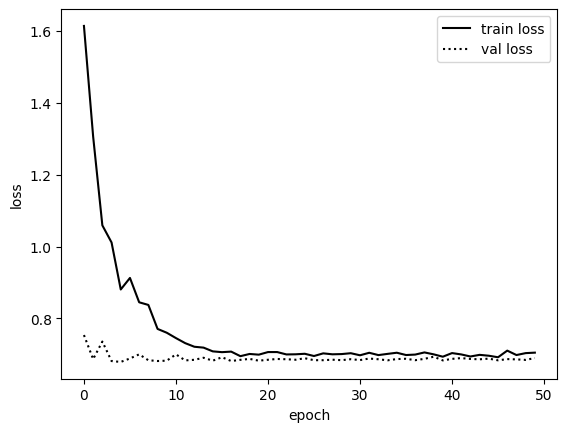

In [31]:
# 学習曲線

plt.plot(history_drop2.history['loss'][:50], label='train loss', linestyle='solid', color='black')
plt.plot(history_drop2.history['val_loss'][:50], label='val loss', linestyle='dotted', color='black')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc='best')

In [32]:
# 正答率

score_train = model.evaluate(X_train.values, y_train.values, verbose=0)
score_val = model.evaluate(X_val.values, y_val.values, verbose=0)
print('accuracy for train data: {0:.4f}'.format(score_train[1]))
print('accuracy for validation data: {0:.4f}'.format(score_val[1]))

accuracy for train data: 0.5312
accuracy for validation data: 0.5622


#### RNNで株価を予測

S&P500の中から金融サービス銘柄をchoice

In [33]:
# データの読み込み

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data_07/stock_price_finance.csv", index_col='Date')
df.head(20)

,AFL,ALL,AXP,AIG,AMP,AON,AJG,AIZ,BAC,BK,...,SYF,TROW,TRV,TFC,USB,UNM,WRB,WFC,WTW,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2016-02-23,25.754879,55.935684,50.141430,43.226501,71.627159,88.234459,34.546665,61.336395,10.759828,30.484337,...,23.857573,56.849514,93.222633,26.359570,32.254322,22.367193,20.019516,40.058964,102.187904,18.589001
2016-02-24,25.867672,56.128784,49.713795,43.107983,71.627159,88.787880,34.634018,61.720989,10.733282,30.232172,...,24.048367,57.147861,93.715050,26.277458,31.897509,22.302938,20.015646,39.650887,101.886528,18.124493
2016-02-25,26.171329,56.825756,50.396183,43.488926,72.434174,89.397530,34.948483,63.798588,10.901402,30.719093,...,24.091732,57.711391,94.397522,26.679834,32.478371,22.752695,20.166780,39.767487,103.092072,18.606525
2016-02-26,26.101921,56.746346,50.387077,43.251888,74.254265,89.819611,34.992149,64.036301,11.237645,31.405979,...,24.221819,57.777699,93.697739,27.344975,32.602825,23.226540,20.228783,40.033993,102.973351,19.079794
2016-02-29,25.819952,55.987614,50.569050,42.498432,72.073593,89.378799,34.808720,62.592522,11.078372,30.771261,...,23.371925,57.272167,92.885704,26.408854,31.963888,22.913322,19.957512,39.076233,103.493919,18.685402
2016-03-01,26.492342,57.178642,51.679047,43.920681,75.559242,89.997833,35.472569,64.564499,11.671227,31.997242,...,23.874918,59.169930,95.140450,27.468159,33.109020,24.206358,20.337288,40.575325,105.494019,19.553062
2016-03-02,26.639839,57.708008,51.970200,43.878368,75.456200,91.348511,35.543110,64.502861,11.911046,32.536324,...,24.499327,59.393681,95.200951,27.763779,33.631786,24.455332,20.546553,41.283230,106.653893,20.008804
2016-03-03,26.453304,57.619770,52.852753,44.250854,76.872787,92.127037,35.878162,65.277565,11.990984,32.771095,...,24.768166,59.948898,94.855392,28.141518,33.830933,24.832802,20.616302,41.449795,106.854836,20.648594
2016-03-04,26.474991,57.681530,53.034718,44.276257,77.662628,92.792976,36.151520,65.242371,12.026514,33.118881,...,24.802862,60.313538,95.373718,28.322174,34.046688,24.977364,20.546553,41.732952,107.028343,21.332211


In [34]:
# データの整理

from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)

test_num = len(df_test)
print(test_num)

252


In [35]:
# 共和分検定

from itertools import combinations
from statsmodels.tsa.vector_ar.vecm import coint_johansen

pairs = []
i = 1
for comb in combinations(df_train.columns, 2):
    prices = df_train.loc[:, comb]
    prices = prices.dropna()
    try:
        jrt = coint_johansen(prices, k_ar_diff=0, det_order=-1)
        if jrt.lr1[0] > jrt.cvt[0, 2] and jrt.lr1[1] < jrt.cvt[1, 0] and jrt.lr2[0] > jrt.cvm[0, 2] and jrt.lr2[1] < jrt.cvm[1, 0]:
            pairs.append(comb)
    except ValueError as error:
        print(i, comb)
    i += 1
        
print(pairs)
print(len(pairs))

[('ALL', 'AJG'), ('ALL', 'CBOE'), ('ALL', 'MCO'), ('ALL', 'MSCI'), ('AIG', 'AON'), ('AIG', 'AJG'), ('AIG', 'MCO'), ('AIG', 'MSCI'), ('AIG', 'WRB'), ('AMP', 'AJG'), ('AMP', 'CBOE'), ('AMP', 'MCO'), ('AMP', 'MSCI'), ('AON', 'BK'), ('AON', 'CBOE'), ('AON', 'CMA'), ('AON', 'FITB'), ('AON', 'BEN'), ('AON', 'HIG'), ('AON', 'HBAN'), ('AON', 'IVZ'), ('AON', 'LNC'), ('AON', 'L'), ('AON', 'MTB'), ('AON', 'MSCI'), ('AON', 'NTRS'), ('AON', 'PBCT'), ('AON', 'PNC'), ('AON', 'PFG'), ('AON', 'PRU'), ('AON', 'SPGI'), ('AON', 'SYF'), ('AON', 'TRV'), ('AON', 'TFC'), ('AON', 'USB'), ('AON', 'UNM'), ('AON', 'WFC'), ('AON', 'ZION'), ('AJG', 'BK'), ('AJG', 'BLK'), ('AJG', 'COF'), ('AJG', 'SCHW'), ('AJG', 'CB'), ('AJG', 'CINF'), ('AJG', 'CFG'), ('AJG', 'RE'), ('AJG', 'FRC'), ('AJG', 'BEN'), ('AJG', 'GL'), ('AJG', 'GS'), ('AJG', 'HIG'), ('AJG', 'IVZ'), ('AJG', 'KEY'), ('AJG', 'LNC'), ('AJG', 'L'), ('AJG', 'MET'), ('AJG', 'MS'), ('AJG', 'NTRS'), ('AJG', 'PBCT'), ('AJG', 'PNC'), ('AJG', 'PFG'), ('AJG', 'PRU'), (

In [36]:
# ポートフォリオの価値の計算

from statsmodels.tsa.vector_ar.vecm import VECM

pair = ['RJF', 'ZION']

modelCoint = VECM(df_train[pair], k_ar_diff=0, deterministic='na', coint_rank=1) # 1次の共和分
res = modelCoint.fit()

pairs_value = res.beta[0] * df[pair[0]] + res.beta[1] * df[pair[1]]

serlen = 70  # 0-69日分のインターバルを考慮

# RNNのためのデータ整形

df_ser = pd.DataFrame()
columns = []
for i in range(serlen + 1):
    df_ser = pd.concat([df_ser, pairs_value.shift(i)], axis=1) 
    columns.append('{0:d} day shift'.format(i))
df_ser.columns = columns
df_ser = df_ser.dropna()
df_ser.head()

/Users/shimizutoorushin/Desktop/大学講義/M1_Class_program/M1_Class/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,0 day shift,1 day shift,2 day shift,3 day shift,4 day shift,5 day shift,6 day shift,7 day shift,8 day shift,9 day shift,...,61 day shift,62 day shift,63 day shift,64 day shift,65 day shift,66 day shift,67 day shift,68 day shift,69 day shift,70 day shift
2016-06-02,3.088647,3.169893,3.490219,2.921695,2.717261,2.245508,2.451901,2.166715,2.176523,1.928327,...,1.487829,1.481764,2.371686,3.048883,3.405139,3.315441,3.503724,3.571919,3.456579,3.192697
2016-06-03,2.693774,3.088647,3.169893,3.490219,2.921695,2.717261,2.245508,2.451901,2.166715,2.176523,...,1.681266,1.487829,1.481764,2.371686,3.048883,3.405139,3.315441,3.503724,3.571919,3.456579
2016-06-06,2.346155,2.693774,3.088647,3.169893,3.490219,2.921695,2.717261,2.245508,2.451901,2.166715,...,1.845379,1.681266,1.487829,1.481764,2.371686,3.048883,3.405139,3.315441,3.503724,3.571919
2016-06-07,1.924873,2.346155,2.693774,3.088647,3.169893,3.490219,2.921695,2.717261,2.245508,2.451901,...,1.238730,1.845379,1.681266,1.487829,1.481764,2.371686,3.048883,3.405139,3.315441,3.503724
2016-06-08,1.751690,1.924873,2.346155,2.693774,3.088647,3.169893,3.490219,2.921695,2.717261,2.245508,...,1.559414,1.238730,1.845379,1.681266,1.487829,1.481764,2.371686,3.048883,3.405139,3.315441


In [37]:
# 説明変数と目的変数の設定

from sklearn.model_selection import train_test_split

X = df_ser.loc[:, '1 day shift':] # 1日以上のインターバル 
y = df_ser['0 day shift'] # その日のリターン

# 訓練/テストデータセットの分割

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=test_num, shuffle=False)

# 訓練データセットのうちの20%をパラメータ設定(検証)用に回す

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8, shuffle=False)

val_num = y_val.shape[0] # 検証データセットの件数
print(val_num)

188


In [38]:
# RNNによる学習

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping

# データの整形

X_train_values = X_train.values.reshape(-1, serlen, 1)
X_val_values = X_val.values.reshape(-1, serlen, 1)
X_test_values = X_test.values.reshape(-1, serlen, 1)
y_train_values = y_train.values.reshape(-1, 1)
y_val_values = y_val.values.reshape(-1, 1)
y_test_values = y_test.values.reshape(-1, 1)

# RNNの構築

tf.random.set_seed(321)

modelRNN = Sequential()
modelRNN.add(SimpleRNN(70, activation='tanh'))
modelRNN.add(Dense(1, activation='linear'))
optimizer = optimizers.RMSprop(learning_rate=0.001, rho=0.99)
modelRNN.compile(optimizer=optimizer, loss='mean_squared_error')
es = EarlyStopping(monitor='loss', patience=5, verbose=1)

# 学習

modelRNN.fit(X_train_values, y_train_values, epochs=100, batch_size=10, verbose=1, callbacks=[es], validation_data=(X_val_values, y_val_values))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.8765 - val_loss: 5.7826
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9900 - val_loss: 12.2625
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1690 - val_loss: 8.5120
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.1645 - val_loss: 7.4239
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9481 - val_loss: 6.8921
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7660 - val_loss: 6.3131
Epoch 6: early stopping


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


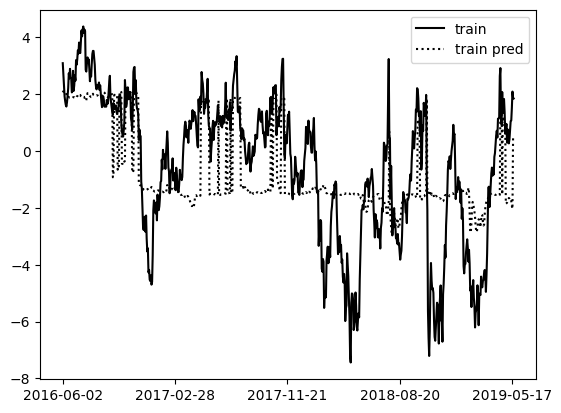

In [39]:
# 学習曲線 (訓練データセット)

y_train_pred = modelRNN.predict(X_train_values).reshape(-1,)
y_val_pred = modelRNN.predict(X_val_values).reshape(-1,)

plt.plot(y_train.index, y_train, label='train', color='black', linestyle='solid')
plt.plot(y_train.index, y_train_pred, label='train pred', color='black', linestyle='dotted')
plt.xticks(y_train.index[np.arange(0, len(y_train.index) + 1, 186)])
plt.legend()

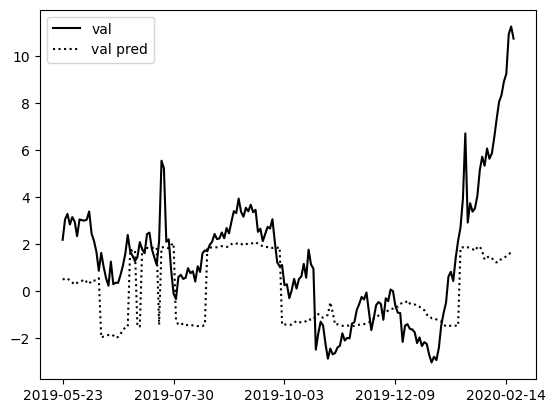

In [40]:
# 学習曲線 (テストデータセット)

plt.plot(y_val.index, y_val, label='val', color='black', linestyle='solid')
plt.plot(y_val.index, y_val_pred, label='val pred', color='black', linestyle='dotted')
plt.xticks(y_val.index[np.arange(0, len(y_val.index) + 1, 46)])
plt.legend()

In [41]:
# 決定係数

from sklearn.metrics import r2_score

print('R score, RNN: {0:.4f}'.format(r2_score(y_val,y_val_pred)))

R score, RNN: 0.1536


#### LSTMで予測

In [42]:
from tensorflow.keras.layers import LSTM

tf.random.set_seed(321)

modelLSTM = Sequential()
modelLSTM.add(LSTM(70, activation='tanh')) 
modelLSTM.add(Dense(1, activation='linear'))
optimizer = optimizers.Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999, amsgrad=True)
modelLSTM.compile(optimizer=optimizer, loss='mean_squared_error')
es = EarlyStopping(monitor='loss', patience=5, verbose=1)
modelLSTM.fit(X_train_values, y_train_values, epochs=100, batch_size=10, verbose=1, callbacks=[es], validation_data=(X_val_values, y_val_values))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.0908 - val_loss: 5.3657
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.9682 - val_loss: 5.7577
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.2504 - val_loss: 6.1931
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.3549 - val_loss: 11.8899
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.9356 - val_loss: 10.6360
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.9336 - val_loss: 5.8857
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2722 - val_loss: 5.6469
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9348 - val_loss: 5.8590
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9949 - val_loss: 6.6443
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7858 - val_loss: 5.5358
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7255 - val_loss: 5.6584
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


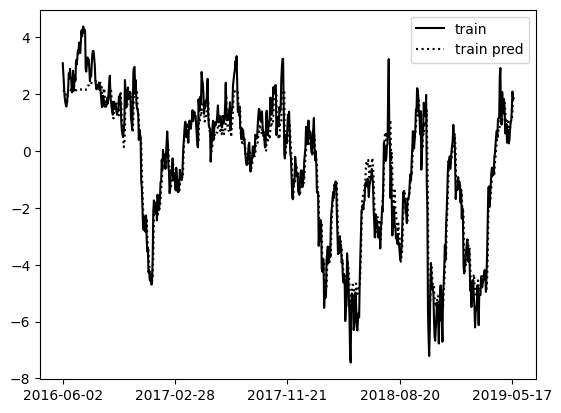

In [43]:
# 学習曲線 (訓練データセット)

y_train_pred = modelLSTM.predict(X_train_values).reshape(-1,)
y_val_pred = modelLSTM.predict(X_val_values).reshape(-1,)

plt.plot(y_train.index, y_train,label='train', color='black', linestyle='solid')
plt.plot(y_train.index, y_train_pred, label='train pred', color='black', linestyle='dotted')
plt.xticks(y_train.index[np.arange(0, len(y_train.index) + 1, 186)])
plt.legend()

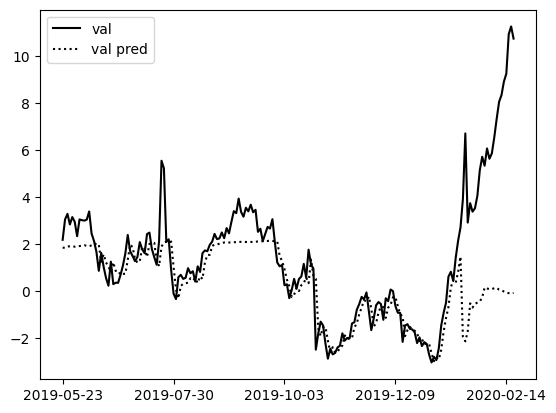

In [44]:
# 学習曲線 (テストデータセット)

plt.plot(y_val.index, y_val, label='val', color='black', linestyle='solid')
plt.plot(y_val.index, y_val_pred, label='val pred', color='black', linestyle='dotted')
plt.xticks(y_val.index[np.arange(0, len(y_val.index) + 1, 46)])
plt.legend()

In [45]:
# 決定係数

from sklearn.metrics import r2_score

print('R score, LSTM: {0:.4f}'.format(r2_score(y_val,y_val_pred)))

R score, LSTM: 0.0901


#### GRUを使ってみる

In [46]:
# GRUの構築

from tensorflow.keras.layers import GRU

tf.random.set_seed(123)


modelGRU = Sequential()
modelGRU.add(GRU(70, activation='tanh')) 
modelGRU.add(Dense(1,activation='linear'))
optimizer = optimizers.Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999, amsgrad=True)
modelGRU.compile(optimizer=optimizer, loss='mean_squared_error')
es = EarlyStopping(monitor='loss', patience=5, verbose=1)

# 学習スタート

modelGRU.fit(X_train_values, y_train_values, epochs=100, batch_size=10, verbose=1, callbacks=[es], validation_data=(X_val_values, y_val_values))

print(len(modelGRU.predict(X_val_values)))
print(len(y_val_values))

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.6486 - val_loss: 10.8627
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0214 - val_loss: 1.8083
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4081 - val_loss: 1.7624
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3460 - val_loss: 1.6600
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3388 - val_loss: 1.6155
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3330 - val_loss: 1.6112
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3291 - val_loss: 1.6505
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3265 - val_loss: 1.7707
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3240 - val_loss: 1.8515
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3223 - val_loss: 1.9416
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3204 - val_loss: 1.9900
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


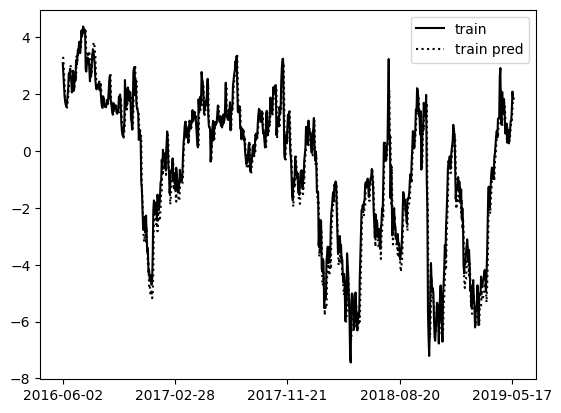

In [47]:
# 学習曲線 (訓練データセット)

y_train_pred = modelGRU.predict(X_train_values).reshape(-1,)
y_val_pred = modelGRU.predict(X_val_values).reshape(-1,)

plt.plot(y_train.index, y_train, label='train', color='black', linestyle='solid')
plt.plot(y_train.index, y_train_pred, label='train pred', color='black', linestyle='dotted')
plt.xticks(y_train.index[np.arange(0, len(y_train.index) + 1, 186)])
plt.legend()

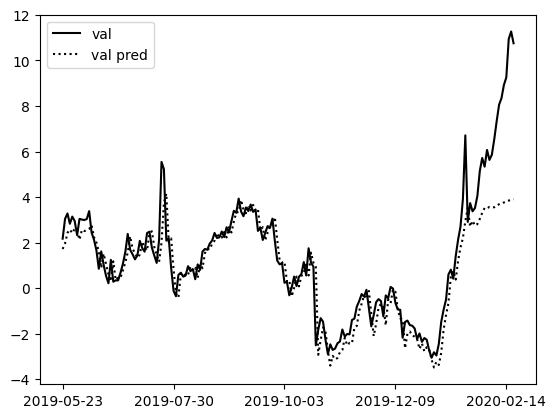

In [48]:
# 学習曲線 (テストデータセット)

plt.plot(y_val.index, y_val, label='val', color='black', linestyle='solid')
plt.plot(y_val.index, y_val_pred, label='val pred', color='black', linestyle='dotted')
plt.xticks(y_val.index[np.arange(0, len(y_val.index) + 1, 46)])
plt.legend()

In [49]:
# 決定係数

print('R score, GRU: {0:.4f}'.format(r2_score(y_val,y_val_pred)))

R score, GRU: 0.7103


#### ニューラルネットワークを共和分法へ応用

1. 閾値を計算

2. ポートフォリオ価値の変動を予測

3-1. ポジションがない場合 $\Rightarrow$ 予想変動 > 閾値となったらポジションを取る

3-2. ポジションがある場合 $\Rightarrow$ 予想変動の符号が反転したときにポジションを解消

In [50]:
# 閾値の候補

diff = (y_train.shift(-1) - y_train).dropna()
diff_p = diff[diff > 0] 
diff_m = diff[diff <= 0]

quintile_range = (diff_m.quantile(0.2), diff_p.quantile(0.8)) # 上位20% & 80%
decile_range = (diff_m.quantile(0.1), diff_p.quantile(0.9)) # 上位10% & 90%

print('quintile threshold', quintile_range)
print('decile threshold', decile_range)

quintile threshold (np.float64(-0.6580995723335121), np.float64(0.5848852794994175))
decile threshold (np.float64(-0.9362916798121723), np.float64(0.8216637678884794))


In [51]:
# GRUを用いた予測値の格納

y_val_pred = modelGRU.predict(X_val_values).reshape(-1,)
y_test_pred = modelGRU.predict(X_test_values).reshape(-1,)

diff_val = (y_val_pred[1:] - y_val[:-1])
diff_test = (y_test_pred[1:] - y_test[:-1])

# 5分位のシミュレーション

pos_q = 0 # 0 for no position, 1 for long positon, -1 for short position
port_val_q = 0.0

for i, diff in enumerate(diff_val[:-1]): # 投資期間終了の直前までループ
    index = diff_val.index[i]
    if pos_q == 0:
        if diff > quintile_range[1]: # ロング・ポジションを組む
            pos_q = 1
            ini_val_q = pairs_value[index] 
            print('long position is made at', index, 'by the value of ', pairs_value[index])
        elif diff < quintile_range[0]: # ショート・ポジションを組む
            pos_q = -1
            ini_val_q = pairs_value[index]
            print('short position is made at', index, 'by the value of', pairs_value[index])
    #符号が反転したら利益を確定
    elif pos_q == 1 and diff < 0: # ロング・ポジションの利益確定
        port_val_q += (pairs_value[index] - ini_val_q)
        pos_q = 0 # ポジションを解消する
        print('long position is liquidated at', index, 'current portfolio value is', port_val_q, 'current pair value is', pairs_value[index])
    elif pos_q == -1 and diff > 0:# ショートポジションの利益確定
        port_val_q -= (pairs_value[index] - ini_val_q)
        pos_q = 0 # ポジションを解消する
        print('short position is liquidated at', index, 'current portfolio value is', port_val_q, 'current pair value is', pairs_value[index])
    
# 満期にポジションは強制終了

index = diff_val.index[-1]
if pos_q == 1:# ロング・ポジションの利益確定
    port_val_q += (pairs_value[index] - ini_val_q)        
    print('long position is liquidated at',index, 'current portfolio value is', port_val_q)
if pos_q == -1:# ショート・ポジションの利益確定
    port_val_q -= (pairs_value[index] - ini_val_q)
    print('short position is liquidated at',index, 'current portfolio value is', port_val_q)

print(port_val_q)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
short position is made at 2019-05-28 by the value of 3.2821465180522225
short position is liquidated at 2019-06-14 current portfolio value is 2.4269443339950385 current pair value is 0.855202184057184
short position is made at 2019-07-23 by the value of 5.547053921210669
short position is liquidated at 2019-08-01 current portfolio value is 7.389052550395583 current pair value is 0.5849457048101243
short position is made at 2020-01-21 by the value of 3.9222815061427525
short position is liquidated at 2020-02-19 current portfolio value is 0.03997355845372397
0.03997355845372397


In [52]:
# 10分位でも同じ計算を試す

pos_d = 0
port_val_d = 0.0

for i, diff in enumerate(diff_val[:-1]):
    index = diff_val.index[i]
    if pos_d == 0:
        if diff > decile_range[1]: # ロング・ポジションを組む
            pos_d = 1
            ini_val_d = pairs_value[index]
            print('long position is made at', index, 'by the value of ', pairs_value[index])

        elif diff < decile_range[0]: # ショート・ポジションを組む
            pos_d = -1
            ini_val_d = pairs_value[index]
            print('short position is made at', index, 'by the value of', pairs_value[index])
    #符号が反転したら利益を確定
    elif pos_d == 1 and diff < 0: # ロング・ポジションの利益確定
        port_val_d += (pairs_value[index] - ini_val_d)
        pos_d = 0 # ポジションを解消する
        print('long position is liquidated at', index, 'current value is', pairs_value[index])
    elif pos_d == -1 and diff > 0:# ショートポジションの利益確定
        port_val_d -= (pairs_value[index] - ini_val_d)
        pos_d = 0 # ポジションを解消する
        print('short position is liquidated at', index, 'current value is', pairs_value[index])

# 満期にポジションは強制終了

index = diff_val.index[-1]       
if pos_d == 1:# ロング・ポジションの解消
    port_val_d += (pairs_value[index] - ini_val_d)
    print('long position is liquidated at', index, 'current value is', port_val_d)
if pos_d == -1:# ショート・ポジションの利益確定
    port_val_d -= (pairs_value[index] - ini_val_d)
    print('short position is liquidated at', index, 'current value is', port_val_d)

print(port_val_d)

# 結局損している

short position is made at 2019-07-23 by the value of 5.547053921210669
short position is liquidated at 2019-08-01 current value is 0.5849457048101243
short position is made at 2020-01-21 by the value of 3.9222815061427525
short position is liquidated at 2020-02-19 current value is -2.3869707755413145
-2.3869707755413145


In [53]:
# 5分位点と10分位点での結果比較

print((port_val_q,port_val_d))

(np.float64(0.03997355845372397), np.float64(-2.3869707755413145))


In [54]:
# 良かった方の閾値

if port_val_q > port_val_d:
    threshold = quintile_range
else:
    threshold = decile_range

print('optimal threshold is', threshold)

optimal threshold is (np.float64(-0.6580995723335121), np.float64(0.5848852794994175))


In [55]:
# テストデータを用いて取引をシミュレーション

pos = 0 # 0 for no position, 1 for long positon, -1 for short position
port_val = 0.0
port_hist = pd.DataFrame()

for i, diff in enumerate(diff_test[:-1]):
    index = diff_test.index[i]
    if pos == 0:
        if diff > threshold[1]: # ロング・ポジションを組む
            pos = 1
            ini_val = pairs_value[index] 
            print('long position is made at', index, 'by the value of ',pairs_value[index])
        elif diff < threshold[0]: # ショート・ポジションを組む
            pos = -1
            ini_val = pairs_value[index]
            print('short position is made at', index, 'by the value of', pairs_value[index])
    #符号が反転したら利益を確定
    if pos == 1 and np.sign(diff) < 0: # ロング・ポジションの利益確定
        port_val += (pairs_value[index] - ini_val)
        pos = 0 # ポジションを解消する
        print('long position is liquidated at', index, 'current value is', pairs_value[index])
    if pos == -1 and np.sign(diff) >= 0: # ショートポジションの利益確定
        port_val -= (pairs_value[index] - ini_val)
        pos = 0 # ポジションを解消する
        print('short position is liquidated at', index, 'current value is', pairs_value[index])
    ser = pd.DataFrame([pos],index = [index])
    port_hist = pd.concat([port_hist, ser])

        
# 満期にポジションは強制終了

index = diff_test.index[-1]
if pos == 1:# ロング・ポジションの利益確定
    port_val += (pairs_value[index] - ini_val)
    print('long position is liquidated at', index, 'current value is', pairs_value[index])
if pos == -1:# ショート・ポジションの利益確定
    port_val -= (pairs_value[index] - ini_val)
    print('short position is liquidated at', index, 'current value is', pairs_value[index])
ser = pd.DataFrame([pos],index = [index])
port_hist = pd.concat([port_hist, ser])

print('Portfolio value is', port_val)

short position is made at 2020-02-21 by the value of 9.370475488439169
short position is liquidated at 2020-04-24 current value is 5.181479764989568
short position is made at 2020-04-27 by the value of 6.3736373937692505
short position is liquidated at 2020-04-30 current value is 5.480736504546627
long position is made at 2020-05-04 by the value of  4.386400850097523
long position is liquidated at 2020-05-07 current value is 6.515093237161381
short position is made at 2020-05-08 by the value of 6.700073547587941
short position is liquidated at 2020-05-20 current value is 5.564552828132456
short position is made at 2020-06-02 by the value of 7.444934883408337
short position is liquidated at 2020-06-08 current value is 4.178857568901449
long position is made at 2020-06-15 by the value of  4.20296031727846
long position is liquidated at 2020-07-06 current value is 5.877728438165406
short position is made at 2020-07-08 by the value of 6.541553182882403
short position is liquidated at 2021-

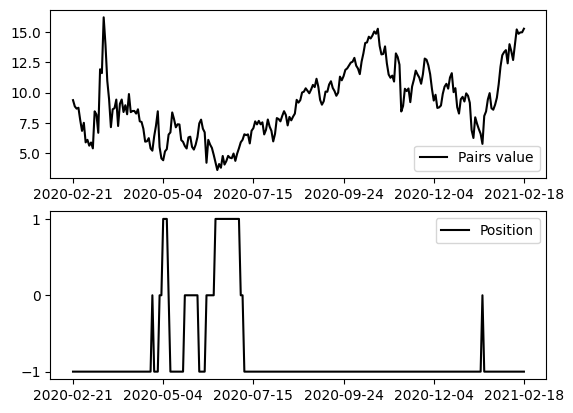

In [56]:
# ポートフォリオの価値の推移

fig8 = plt.figure()

ax1 = fig8.add_subplot(211)
ax1.plot(pairs_value[diff_test.index].index, pairs_value[diff_test.index].values, color='black', label='Pairs value')
ax1.set_xticks(pairs_value[diff_test.index].index[::50])
ax1.legend()

# ポジションの変動

ax2 = fig8.add_subplot(212)
ax2.plot(port_hist.index, port_hist.values, color='black', label = 'Position')
ax2.set_yticks([-1, 0, 1])
ax2.set_xticks(port_hist.index[::50])
ax2.legend()